# Maximum Diversification — a quantitative teardown \U0001F52C
### Closed form on the correlation matrix · brute-force check · the equal-volatility collapse · out-of-sample DR

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Usefulness: Mirage](https://img.shields.io/badge/Usefulness-Mirage-c0392b?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). Two controls
carry the study: the **degenerate case**, where equal volatilities make maximum diversification
and minimum variance the same problem (so the implementation can be proved correct), and
**inverse-volatility weighting**, the free competitor that decides whether the correlation
matrix is earning anything.

> ⚠️ **Not investment advice.** Total-return closes from Yahoo! Finance pinned as-of the date
> in [`docs/results.md`](../docs/results.md).
>
> \U0001F4A1 **The `\U0001F4A1 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

In [2]:
from max_div import data, strategy as st

px = data.load_prices()
rets = px.pct_change()
panels = {"sectors": [c for c in data.SECTORS if rets[c].notna().sum() > 1500],
          "multi-asset": [c for c in data.MULTI if rets[c].notna().sum() > 3000]}
print(f"as-of {data.AS_OF}")
for tag, cols in panels.items():
    sub = rets[cols].dropna(how="any")
    v = sub.std() * np.sqrt(252)
    print(f"  {tag:12s} {len(cols):2d} assets, vol {v.min():.1%} to {v.max():.1%}, "
          f"{len(sub):,} sessions")

as-of 2026-06-30
  sectors      11 assets, vol 15.6% to 31.9%, 2,017 sessions
  multi-asset  10 assets, vol 7.0% to 28.0%, 4,835 sessions


## Verdict, up front

| Axis | Stamp | Why |
|---|---|---|
| **Signal** | Real | It is a genuinely different objective. The most diversified portfolio's weights differ from the minimum-variance ones by **100%** of the book on the multi-asset panel and 35% on sectors, and it achieves an in-sample diversification ratio of **1.78** against 1.21 — by construction, but it is worth confirming the implementation does what the formula says. On a panel of equal-volatility assets the two objectives collapse into one, and the two weight vectors agree to 1.9e-16, which is the boundary of the distinction. |
| **Usefulness** | Mirage | The objective is delivered but the advantage is not free money. Out of sample the realised diversification ratio slips to 1.79 (+1% of the in-sample value), realised volatility is **9.95%** against 7.23% for plain inverse volatility (paired *t* = -2.96) and 9.58% for 1/N, and it turns over 0.32 a rebalance against 0.08. It beats the free competitor on **0 of 2** panels. |

> \U0001F4A1 **In plain words.** The objective is real and distinct. What it buys, out of
> sample, is mostly available for free.

## 1 · The claim, as algebra

- **H₁.** ``DR(w) = (w'σ)/√(w'Σw)`` is maximised by ``w ∝ diag(σ)⁻¹ C⁻¹ 1`` (unconstrained),
  where ``C`` is the correlation matrix.
- **H₂.** With equal volatilities, ``DR`` is a monotone decreasing function of portfolio
  variance, so the MDP **is** the minimum-variance portfolio.
- **H₃.** With dispersed volatilities the two differ materially.
- **H₄.** Out of sample, the MDP's realised volatility beats inverse-volatility weighting.

## 2 · The closed form, checked by brute force

In [3]:
cov3 = np.outer([0.10, 0.18, 0.30], [0.10, 0.18, 0.30]) *        (np.full((3, 3), 0.25) + 0.75 * np.eye(3))
w_star = st.max_div_weights(cov3)
grid = np.linspace(0, 1, 201)
best, best_dr = None, -np.inf
for a in grid:
    for b in grid:
        if a + b > 1:
            continue
        w = np.array([a, b, 1 - a - b])
        dr = st.diversification_ratio(w, cov3)
        if dr > best_dr:
            best, best_dr = w, dr
print(f"closed form : {np.round(w_star, 4)}  DR {st.diversification_ratio(w_star, cov3):.6f}")
print(f"brute force : {np.round(best, 4)}  DR {best_dr:.6f}")

closed form : [0.5294 0.2941 0.1765]  DR 1.414214
brute force : [0.53  0.295 0.175]  DR 1.414205


## 3 · The teardown

### 3.1 The degenerate case — where the two objectives are one

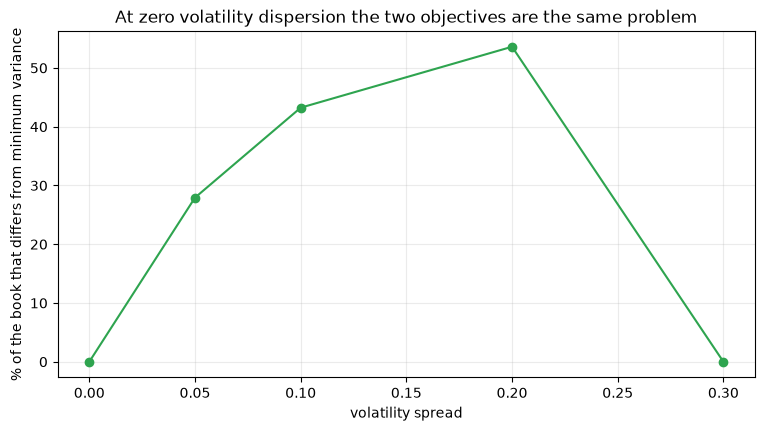

,share of book differing
volatility spread,
0.0000,0.0000
0.0500,0.2792
0.1000,0.4323
0.2000,0.5360
0.3000,0.0000


In [4]:
rows = []
for spread in (0.0, 0.05, 0.1, 0.2, 0.3):
    n = 10
    vols = np.linspace(0.15 - spread / 2, 0.15 + spread / 2, n)
    corr = np.full((n, n), 0.35); np.fill_diagonal(corr, 1.0)
    c = np.outer(vols, vols) * corr
    gap = np.abs(st.max_div_weights(c) - st.min_variance_weights(c)).sum() / 2
    rows.append({"volatility spread": spread, "share of book differing": gap})
d = pd.DataFrame(rows).set_index("volatility spread")
fig, ax = plt.subplots(figsize=(9, 4.5))
(d * 100).plot(ax=ax, marker="o", color="#2ea44f", legend=False)
ax.set_ylabel("% of the book that differs from minimum variance")
ax.set_title("At zero volatility dispersion the two objectives are the same problem")
plt.show()
d.round(4)

> \U0001F4A1 **In plain words.** This is the honest boundary of the "different objective"
> claim. Everything the MDP does differently comes from *volatility dispersion*, not from
> correlations alone.

### 3.2 The full scoreboard, both panels

In [5]:
all_wf = {}
for tag, cols in panels.items():
    all_wf[tag] = st.walk_forward(rets[cols].dropna(how="any"), window=252, step=63,
                                  cost_bps=5.0)
    print(f"--- {tag} ---")
    print(st.summarise(all_wf[tag])[["realised_vol", "sharpe", "dr_in", "dr_out",
                                     "dr_slippage", "turnover", "effective_n"]]
          .round(4).to_string())
    print()

--- sectors ---
             realised_vol  sharpe  dr_in  dr_out  dr_slippage  turnover  effective_n
method                                                                              
max_div            0.1728  1.0439 1.3326  1.4362       0.0777    0.4581       4.2798
min_var            0.1391  0.6938 1.2339  1.2572       0.0189    0.3743       3.0649
inv_vol            0.1549  0.8590 1.2827  1.3772       0.0737    0.0726      10.5162
equal              0.1604  0.8812 1.2857  1.3859       0.0780    0.0357      11.0000
risk_parity        0.1535  0.8743 1.3057  1.4016       0.0734    0.0807      10.3513



--- multi-asset ---
             realised_vol  sharpe  dr_in  dr_out  dr_slippage  turnover  effective_n
method                                                                              
max_div            0.0995  0.7699 1.7821  1.7939       0.0066    0.3170       4.2139
min_var            0.0573  0.4495 1.2094  1.2348       0.0210    0.1642       1.4690
inv_vol            0.0723  0.7643 1.7736  1.7762       0.0014    0.0829       7.8122
equal              0.0958  0.7126 1.6093  1.6514       0.0262    0.0139      10.0000
risk_parity        0.1018  0.5469 1.4731  1.5136       0.0275    0.2520       6.9967



### 3.3 Paired tests, and the free competitor

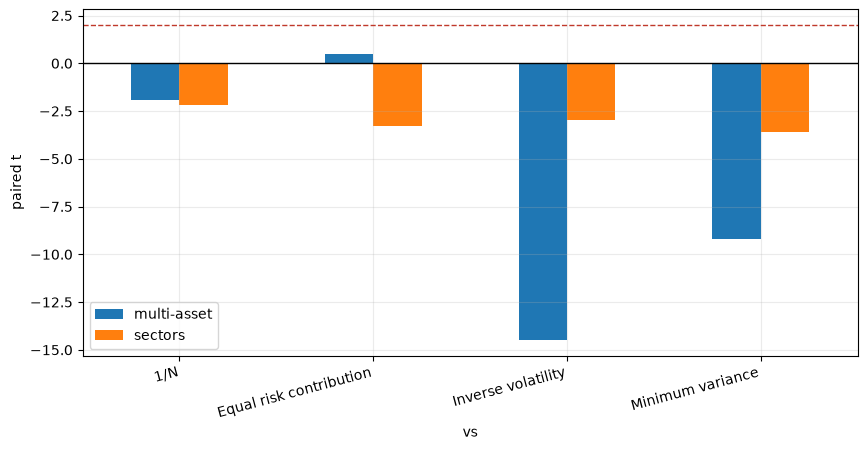

,panel,vs,vol diff,t (MDP quieter > 0),MDP wins
0,sectors,Minimum variance,0.0337,-3.5985,0.1071
1,sectors,Inverse volatility,0.0179,-2.9554,0.1429
2,sectors,1/N,0.0124,-2.1698,0.2857
3,sectors,Equal risk contribution,0.0193,-3.2667,0.1429
4,multi-asset,Minimum variance,0.0422,-9.2124,0.0278
5,multi-asset,Inverse volatility,0.0272,-14.4886,0.0278
6,multi-asset,1/N,0.0037,-1.9443,0.2778
7,multi-asset,Equal risk contribution,-0.0023,0.4845,0.4028


In [6]:
rows = []
for tag, wf in all_wf.items():
    for o in ("min_var", "inv_vol", "equal", "risk_parity"):
        p = st.paired_test(wf, "max_div", o)
        rows.append({"panel": tag, "vs": st.METHOD_LABEL[o], "vol diff": p["diff"],
                     "t (MDP quieter > 0)": -p["t"], "MDP wins": p["win_rate"]})
d = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(10, 4.5))
d.pivot(index="vs", columns="panel", values="t (MDP quieter > 0)").plot.bar(ax=ax)
ax.axhline(0, color="k", lw=1); ax.axhline(2, color="#c0392b", ls="--", lw=1)
ax.set_ylabel("paired t"); ax.legend(title="")
plt.setp(ax.get_xticklabels(), rotation=15, ha="right")
plt.show()
d.round(4)

### 3.4 The ratio, promised and delivered

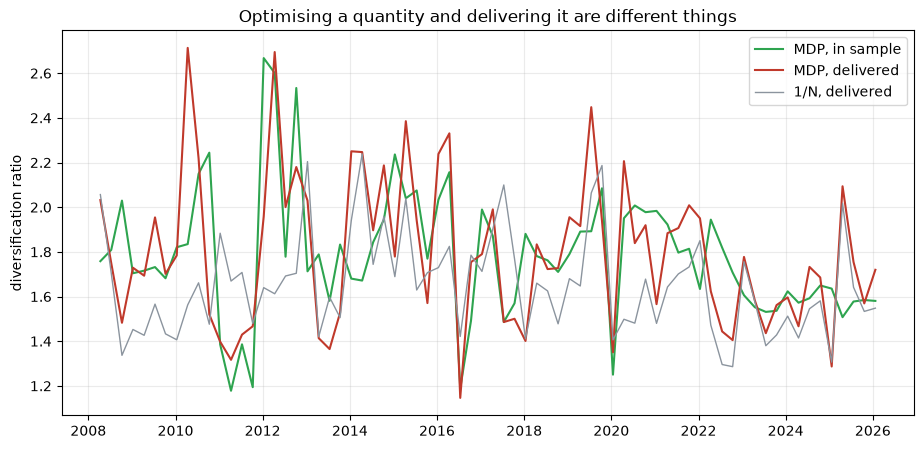

method   equal  inv_vol  max_div  min_var  risk_parity
count  72.0000  72.0000  72.0000  72.0000      72.0000
mean    0.0300   0.0090   0.0150   0.0210       0.0290
std     0.1430   0.1540   0.1580   0.1240       0.1270
min    -0.2520  -0.3210  -0.3230  -0.3070      -0.2470
25%    -0.0400  -0.0830  -0.0680  -0.0360      -0.0520
50%     0.0150   0.0190   0.0140   0.0000       0.0190
75%     0.0950   0.0920   0.1070   0.0300       0.0950
max     0.4320   0.4340   0.4790   0.4440       0.4260


In [7]:
wf = all_wf["multi-asset"]
piv_in = wf.pivot(index="date", columns="method", values="dr_in")
piv_out = wf.pivot(index="date", columns="method", values="dr_out")
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(piv_in.index, piv_in["max_div"], lw=1.5, color="#2ea44f", label="MDP, in sample")
ax.plot(piv_out.index, piv_out["max_div"], lw=1.5, color="#c0392b", label="MDP, delivered")
ax.plot(piv_out.index, piv_out["equal"], lw=1, color="#8b949e", label="1/N, delivered")
ax.set_ylabel("diversification ratio"); ax.legend()
ax.set_title("Optimising a quantity and delivering it are different things")
plt.show()
print((piv_out / piv_in - 1).describe().round(3).to_string())

### 3.5 Concentration and turnover

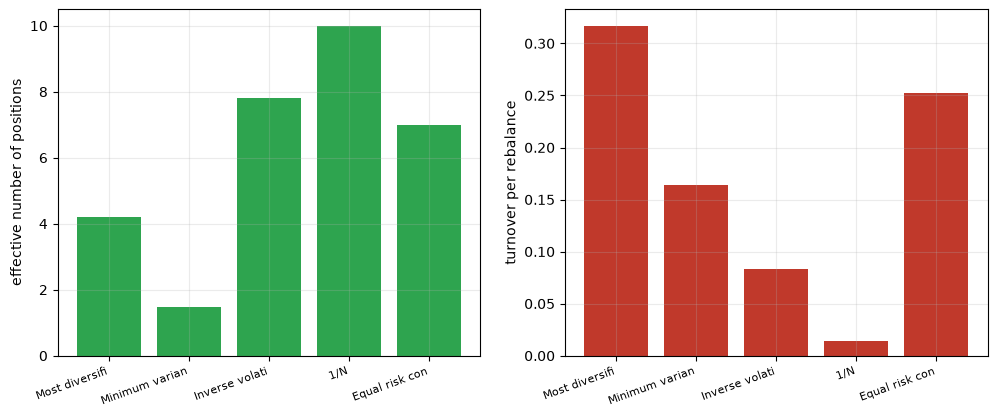

,effective_n,max_weight,turnover
method,,,
max_div,4.2140,0.4010,0.3170
min_var,1.4690,0.8200,0.1640
inv_vol,7.8120,0.2070,0.0830
equal,10.0000,0.1000,0.0140
risk_parity,6.9970,0.2460,0.2520


In [8]:
s = st.summarise(all_wf["multi-asset"])
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar([st.METHOD_LABEL[m][:14] for m in s.index], s["effective_n"], color="#2ea44f")
axes[0].set_ylabel("effective number of positions")
axes[1].bar([st.METHOD_LABEL[m][:14] for m in s.index], s["turnover"], color="#c0392b")
axes[1].set_ylabel("turnover per rebalance")
for a in axes:
    plt.setp(a.get_xticklabels(), rotation=20, ha="right", fontsize=8)
plt.show()
s[["effective_n", "max_weight", "turnover"]].round(3)

### 3.6 Window sensitivity

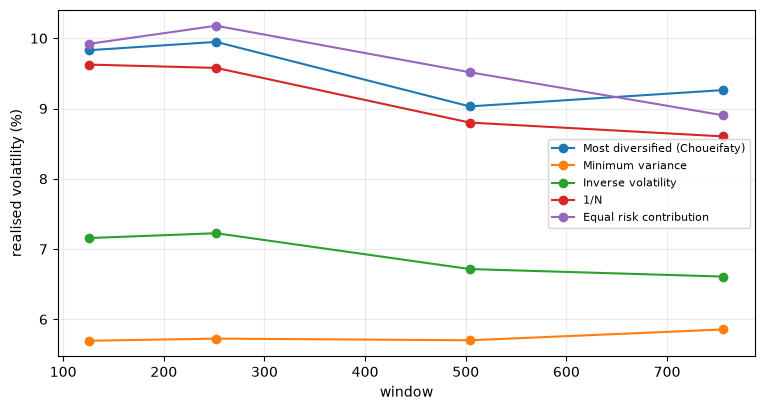

,Most diversified (Choueifaty),Minimum variance,Inverse volatility,1/N,Equal risk contribution
window,,,,,
126,0.0983,0.0569,0.0716,0.0963,0.0992
252,0.0995,0.0573,0.0723,0.0958,0.1018
504,0.0903,0.0570,0.0672,0.0880,0.0952
756,0.0926,0.0586,0.0661,0.0860,0.0890


In [9]:
rows = []
sub = rets[panels["multi-asset"]].dropna(how="any")
for w in (126, 252, 504, 756):
    s_ = st.summarise(st.walk_forward(sub, window=w, step=63, cost_bps=5.0))
    rows.append({"window": w, **{st.METHOD_LABEL[m]: s_.loc[m, "realised_vol"]
                                 for m in st.METHODS}})
d = pd.DataFrame(rows).set_index("window")
fig, ax = plt.subplots(figsize=(9, 4.5))
(d * 100).plot(ax=ax, marker="o")
ax.set_ylabel("realised volatility (%)"); ax.legend(fontsize=8, title="")
plt.show()
d.round(4)

## 4 · The verdict

In [10]:
summary = {}
for tag, wf in all_wf.items():
    s_ = st.summarise(wf)
    summary[tag] = {"MDP vol": s_.loc["max_div", "realised_vol"],
                    "inv-vol vol": s_.loc["inv_vol", "realised_vol"],
                    "min-var vol": s_.loc["min_var", "realised_vol"],
                    "1/N vol": s_.loc["equal", "realised_vol"],
                    "t vs inv-vol": -st.paired_test(wf, "max_div", "inv_vol")["t"],
                    "DR delivered": s_.loc["max_div", "dr_out"],
                    "DR slippage": s_.loc["max_div", "dr_slippage"]}
pd.DataFrame(summary).T.round(4)

,MDP vol,inv-vol vol,min-var vol,1/N vol,t vs inv-vol,DR delivered,DR slippage
sectors,0.1728,0.1549,0.1391,0.1604,-2.9554,1.4362,0.0777
multi-asset,0.0995,0.0723,0.0573,0.0958,-14.4886,1.7939,0.0066


## 5 · Going further

- **The maximum-Sharpe interpretation**: the MDP is optimal if expected return is proportional
  to volatility. Test that assumption directly and the study becomes a return study.
- **Shrinkage inside the MDP** (study 975), and **hierarchical clustering** (study 976): the
  three risk-based schemes are rarely compared on the same panel with the same estimator, and
  this desk now has all three.
- **Factor attribution** of the MDP's returns (Scherer 2011) — how much is low-volatility, how
  much is genuinely the construction?